In [2]:
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from mpl_toolkits.mplot3d import Axes3D

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from nltk import pos_tag
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS

import gensim
from gensim import corpora
from gensim.models import Word2Vec, LsiModel, LdaModel, CoherenceModel

from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix

import text_mining_utils as tmu

warnings.filterwarnings('ignore')

NLTK_PATH = "../../../data/auto/"
nltk.data.path.append(NLTK_PATH)

resources = [
    'punkt', 'punkt_tab', 'wordnet', 'omw-1.4', 'stopwords', 
    'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng'
]

for res in resources:
    nltk.download(res, download_dir=NLTK_PATH)

[nltk_data] Downloading package punkt to ../../../data/auto/...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to ../../../data/auto/...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to ../../../data/auto/...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to ../../../data/auto/...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to ../../../data/auto/...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ../../../data/auto/...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ../../../data/auto/...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [3]:
# ==========================================
# Loading data
# ==========================================
try:
    df = pd.read_csv("../../../data/policy/combined_policy_docs_chunked.csv", encoding='utf-8-sig')

    # Ensure titles are strings and handle missing values
    df['Title'] = df['Title'].fillna('').astype(str)

    # Remove rows with failed extraction or missing content
    df = df[df['Content'] != 'N/A']
    df = df.dropna(subset=['Content'])

    # Combine Title and Content for analysis
    df['Content'] = df['Title'] + " " + df['Content']

    print(f"Successfully loaded {len(df)} documents.")
except FileNotFoundError:
    print("Error: File not found. Please run the scraper first.")
    exit()

Successfully loaded 1172 documents.


In [4]:
# ==========================================
# Base stop words initialization
# ==========================================

# Start with SpaCy's comprehensive English list
stop_words = set(SPACY_STOP_WORDS)

# Add Standard NLTK Stopwords
stop_words.update(set(stopwords.words('english')))

# Add French Stopwords
try:
    french_stopwords = set(stopwords.words('french'))
    stop_words.update(french_stopwords)
except:
    print("Warning: French stopwords not found.")

# ==========================================
# Base stop words initialization
# ==========================================

# Start with SpaCy's comprehensive English list
stop_words = set(SPACY_STOP_WORDS)

# Add Standard NLTK Stopwords
stop_words.update(set(stopwords.words('english')))

# Add French Stopwords
try:
    french_stopwords = set(stopwords.words('french'))
    stop_words.update(french_stopwords)
except:
    print("Warning: French stopwords not found.")

# PDF & Scraping Artifacts
pdf_stopwords = [
    'pdf', 'qxp', 'page', 'copyright', 'reserved', 'www', 'http', 'https', 'com', 'org',
    'figure', 'table', 'annex', 'appendix', 'footnote', 'endnote',
    'isbn', 'bibliography', 'citation', 'reference', 'metadata', 'docx',
    'executive summary', 'draft', 'matrix', 'blueprint', 'snapshot', 'chart', 'brochure'
]

# B. Policy, Legal, & Bureaucratic Jargon
# We only remove structural noise and archaic legalese.
# We KEEP abstract nouns (policy, strategy, enjeu, objective) as they are analysis-relevant.

policy_stopwords = [
    # ENGLISH
    
    # STRUCTURAL TERMS (True Noise)
    'section', 'chapter', 'part', 'title', 'article', 'clause', 'paragraph', 'subparagraph',
    'schedule', 'exhibit', 'supplement', 'addendum', 'preamble', 'recital', 'report',
    'coppa', 'ferpa', 'enact', 'bit'
    
    # ARCHAIC CONNECTORS (True Noise)
    'herein', 'therein', 'thereof', 'whereof', 'hereby', 'whereby', 'hereinafter', 'thereafter',
    'aforementioned', 'foregoing', 'henceforth', 'whereto', 'whereupon', 'notwithstanding',
    'pursuant', 'thereto', 'thereunder', 'hereto',

    # GENERIC PROCESS VERBS (Safe to remove)
    'shall', 'must', 'may', 'might', 'could', 'would', 'should', 'will',
    'require', 'requires', 'required', 'ensure', 'ensures', 'seek', 'seeks', 'seeking',
    'establish', 'establishes', 'promote', 'promotes', 'promoting', 'maintain', 'respect',

    # VAGUE QUALIFIERS (Safe to remove)
    'various', 'several', 'multiple', 'certain', 'relevant', 'appropriate',
    'regarding', 'concerning', 'involving', 'accordance', 'relate', 'relates', 'relating',
    'furthermore', 'moreover', 'therefore', 'thus', 'hence', 'however', 'although',
    'including', 'etc', 'etcetera',

    # FRENCH
    
    # STRUCTURAL TERMS
    'article', 'chapitre', 'section', 'partie', 'titre', 'paragraphe', 'alinea', 'annexe',
    'appendice', 'expos', 'des', 'motifs', 'disposition',

    # ARCHAIC CONNECTORS
    'susmentionn', 'prcit', 'nonobstant', 'par drogation', 'en', 'consquence',
    'eu', 'gard', 'aux fins', 'selon', 'conformment', 'outre', 'ladite', 'ledit',

    # GENERIC PROCESS VERBS
    'doit', 'devrait', 'pourrait', 'vouloir', 'exiger', 'requis', 'assurer', 'garantir',
    'rechercher', 'tablir', 'promouvoir', 'maintenir', 'respecter', 'concernant',

    # VAGUE QUALIFIERS
    'divers', 'plusieurs', 'multiple', 'particulier', 'certain', 'aussi',
    'de plus', 'en outre', 'par consquent', 'donc', 'ainsi', 'cependant', 'bien que',
    'notamment', 'entre autres', 'comme', 'ainsi', 'toute', 'tous', 'cette', 'plus', 'leurs'
]

# Geo Noise
geo_stopwords = [
    'ireland', 'irish', 'france', 'french', 'usa', 'america', 'australia', 'australian',
    'country', 'nation', 'national', 'state', 'government', 'federal', 'ministry', 'department',
    'gouvernement', 'ministre', 'dtat', 'republic', 'pittsburg', 'antioch', 'medina', 'winterset', 'sara',
    'washington', 'california', 'massachusetts', 'oregon', 'sweden', 'unified', 'district'
]

# Tech Noise
tech_stopwords = [
    'artificial', 'intelligence', 'ai', 'genai', 'generative', 'model', 'models', 'llm',
    'algorithm', 'algorithms', 'machine', 'learning', 'data', 'dataset', 'datasets', 
    'digital', 'numérique', 'computer', 'software', 'hardware', 'technology', 'technological',
    'platform', 'online', 'internet', 'web', 'electronic', 'tool', 'system', 'device',
    'application', 'app', 'service', 'broadband', 'connectivity', 'vendor', 'player', 'enterprise',
    'artificielle', 'ia', 'gen', 'generatif', 
    'modle', 'modles', 'apprentissage', 'donn', 'numrique', 'ordinateur', 'logiciel', 
    'matriel', 'technologie', 'plateforme', 'ligne', 'ectronique', 'outil', 'systme', 'dispositif',
    'générative', 'intelligent', 'edge', 'gpt', 'openai', 'microsoft', 'google', 'amazon', 'meta', 'ibm', 'nvidia', 'intel', 
    'gemini', 'deepseek', 'anthropic', 'claude', 'embedding', 'transformer', 'natural language', 'climate change', 'ieee',
    'architecture', 'chatgtp', 'copilot', 'kwyk'
]

# Education Noise
ed_stopwords = [
    'school', 'education', 'educational', 'pupil', 'classroom', 'learning',
    'cole', 'educatif', 'enseignant', 'professeur', 'programme', 'apprentissage',
    'enseignement', 'formation', 'établissement', 'covid', 'showcase', 'deliverable', 'post', 'primary', 
    'technical',
]

# Org & Name Noise
org_and_name = [
    'adam', 'mary', 'jensen', 'abraham', 'lincoln', 'knight', 'kim', 'guez',
    'oecd', 'cbs', 'webwise', 'cosn', 'dlf', 'scoilnet', 'deap', 
    'dne', 'men', 'parliament', 'commissioner', 'public sector',
    'cipa', 'protection act', 'oide', 'tie', 'cpd', 
]

# Vague Noise
noise = [
    'feel', 'like', 'everybody', 'actually', 'kid', 'employee', 'min', 'box', 'loop', 
    'black', 'asset', 'typical', 'era', 'acquire', 'behavioral', 'behavioural', 
    'revolution', 'emission', 'talent', 'billion', 'count', 'witness', 'operator', 
    'interim', 'resourced', 'resourcing', 'july', 'round', 'support work', 'dashboard', 'ela', 
    'estonia', 'pisa', 'perspectives', 'final', 'total', 'april', 'describe', 'visit',
    'original', 'sample', 'low', 'answer', 'ask', 'efficacy', 'deepen', 'enhance',
    'author', 'researcher', 'mission', 'personnel', 'palo', 'alto',    
    'winterset', 'card', 'use', 'lot', 'enable', 'constituent', 'session',
    'policy', 'use', 'august', 'document', 'member', 'organisation', 'goal', 
    'long term', 'desirable', 'young', 'nsw', 'ite', 'commonwealth', 'aied', 'australasian',
    'perplexed', 'guidetoaiinschools', 'nenufsd', 'dent', 'fig', 'fee', 'want', 'prof', 'stu'
]

# Fragments
fragment_stopwords = [
    'ing', 'tion', 'ment', 'ness', 'ly', 'able', 'ive', 'ent', 'ant', 'ence', 'ance', 
    'ali', 'gue', 'rod', 'rodr', 'educa', 'evi',
]

# MERGE ALL
stop_words.update(pdf_stopwords)
stop_words.update(policy_stopwords)
stop_words.update(geo_stopwords)
stop_words.update(tech_stopwords)
stop_words.update(ed_stopwords)
stop_words.update(fragment_stopwords)
stop_words.update(org_and_name)
stop_words.update(noise)

In [ ]:
# ==========================================
# Refined cleaning function
# ==========================================

# Ensure helper functions/classes are available
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Maps NLTK POS tags to WordNet POS tags."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


# 3. ADVANCED CLEANING FUNCTION (Updated with French Contraction Expansion)

def clean_text(text):
    """
    Applies regex, contraction removal, accent normalization (ASCII), POS tagging, 
    lemmatization, and stopword removal for LDA.
    
    Returns a list of tokens.
    """
    
    # REMOVE CONTRACTIONS (Robustly handles accented characters)
    # Step A: Separate the apostrophe from the word (e.g., "l'éducation" -> "l éducation")
    text = re.sub(r"([a-zA-ZàâäéèêëïîôùûüÿçÀÂÄÉÈÊËÏÎÔÙÛÜŸÇ])'", r"\1 ", text)
    
    # Step B: Remove the now-isolated contraction letters (l, d, c, j, qu, etc.)
    text = re.sub(r"\b(l|d|c|j|qu|lorsqu|puisqu)\b", "", text, flags=re.IGNORECASE)

    # Lowercase
    text = str(text).lower()
    
    # Normalize Accents (Convert French chars to ASCII -> é becomes e)
    # CRITICAL FOR LDA: This ensures "education" and "éducation" are counted as the same word.
    # Keep accents for LDA, comment out the line below.
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # Remove URLs and HTML
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove Reference Citations and Artifacts
    text = re.sub(r'\[\d+\]', '', text)
    text = re.sub(r'\(\s*see\s+[^\)]+\)', '', text)
    text = re.sub(r'footnote\s*\d+', '', text)
    
    # Remove Punctuation/Separators
    text = re.sub(r'[\_\-\.\/\\]', ' ', text)
    
    # Remove Standalone Numbers
    text = re.sub(r'\b\d+\b', ' ', text)

    # Remove non-letters (only a-z remains after ascii normalization)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove single chars
    text = re.sub(r'\s+[a-z]\s+', ' ', text)
    
    # Tokenize
    words = text.split()
    
    # POS Tagging + Lemmatization
    tagged_words = pos_tag(words)
    lemmatized_words = []
    
    for word, tag in tagged_words:
        wn_tag = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=wn_tag)
        lemmatized_words.append(lemma)
    
    # Remove Stopwords and Short Words
    filtered_words = [word for word in lemmatized_words if word not in stop_words and len(word) > 2]
    
    # Return LIST of tokens (Required for Gensim LDA)
    return filtered_words

# APPLICATION
print(f"Cleaning {len(df)} documents (this may take a moment due to POS tagging)...")

# Apply the function to the Content column
texts = df['Content'].apply(clean_text).tolist()

# Filter out empty documents
texts = [t for t in texts if len(t) > 0]
print(f"Valid documents after cleaning: {len(texts)}")

Cleaning 1172 documents (this may take a moment due to POS tagging)...
Valid documents after cleaning: 1172


In [6]:
# ==========================================
# Create dictionary & filter for LDA
# ==========================================

# Create Dictionary
dictionary = corpora.Dictionary(texts)

# Filter Extremes
dictionary.filter_extremes(no_below=5, no_above=0.4)

print(f"Dictionary size after filtering: {len(dictionary)} unique tokens.")

# Create Corpus (Bag of Words)
doc_term_matrix = [dictionary.doc2bow(text) for text in texts]

print("Preprocessing complete. Ready for LDA.")

Dictionary size after filtering: 4860 unique tokens.
Preprocessing complete. Ready for LDA.


# Global LDA

In [7]:
# ==========================================
# PART A: Determine global optimal topics
# ==========================================

coher_vals2 = []
lda_models = []
limit = 15; start=2; step=1  

for num_topics in range(start, limit+1, step):
    # Train LDA
    lda_model = LdaModel(
        corpus=doc_term_matrix,
        id2word=dictionary,
        num_topics=num_topics,
        chunksize=2000,
        passes=30,
        iterations=500,
        random_state=43,
        update_every=1, # Update model after every chunksize docs
        alpha='auto',   # Learn asymmetric prior from data (usually better)
        eta='auto'      # Learn asymmetric topic-word prior
    )
    
    lda_models.append(lda_model)
    
    # Calculate Coherence
    coherence_model = CoherenceModel(
        model=lda_model, 
        texts=texts, 
        dictionary=dictionary, 
        coherence='c_v'
    )
    coher_vals2.append(coherence_model.get_coherence())
    print(f"Topics: {num_topics} | Coherence Score: {coher_vals2[-1]:.4f}")

Topics: 2 | Coherence Score: 0.3235
Topics: 3 | Coherence Score: 0.4159
Topics: 4 | Coherence Score: 0.6212
Topics: 5 | Coherence Score: 0.5885
Topics: 6 | Coherence Score: 0.5715
Topics: 7 | Coherence Score: 0.5537
Topics: 8 | Coherence Score: 0.5344
Topics: 9 | Coherence Score: 0.5541
Topics: 10 | Coherence Score: 0.5258
Topics: 11 | Coherence Score: 0.5450
Topics: 12 | Coherence Score: 0.5759
Topics: 13 | Coherence Score: 0.5376
Topics: 14 | Coherence Score: 0.5610
Topics: 15 | Coherence Score: 0.5768



Plot successfully saved to: ./img/optimal_number_of_topics.png


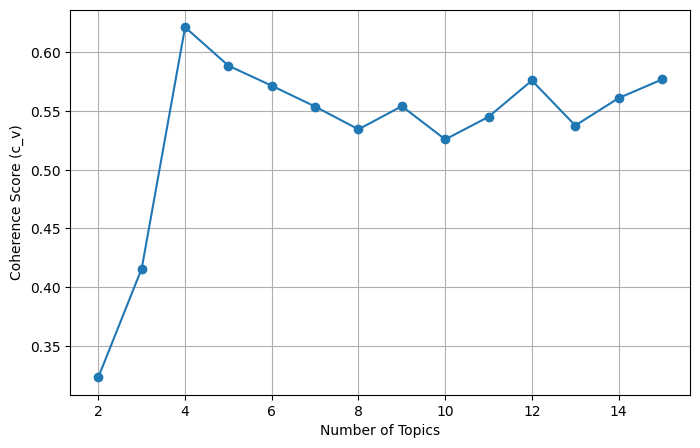

In [8]:
# ==========================================
# Plot coherence scores
# ==========================================

x = range(start, limit+1, step)
plt.figure(figsize=(8,5))
plt.plot(x, coher_vals2, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
# plt.title("Optimal Number of Topics")
plt.grid(True)
# Change this to whatever folder name you want
folder_name = "./img/"
file_name = "optimal_number_of_topics.png"

# Create the folder if it doesn't exist yet
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# Combine them into a full path (handles Windows/Mac differences automatically)
full_path = os.path.join(folder_name, file_name)

plt.savefig(full_path, dpi=300, bbox_inches='tight')

print(f"\nPlot successfully saved to: {full_path}")
plt.show()

In [9]:
# Find the index of the maximum coherence score
optimal_num_topics_index = coher_vals2.index(max(coher_vals2))
optimal_num_topics = x[optimal_num_topics_index]
print(f"Optimal Number of Topics: {optimal_num_topics}")

Optimal Number of Topics: 4


In [10]:
# Select the best model from our list
best_lda_model = lda_models[optimal_num_topics_index]
# Print the topics
# Each topic is a list of (word, probability) tuples
print(f"\nTop 10 words for each of the {optimal_num_topics} topics:")
topics = best_lda_model.print_topics(num_words=10)
for topic_id, topic_content in topics:
    print(f"Topic {topic_id}: {topic_content}")


Top 10 words for each of the 4 topics:
Topic 0: 0.027*"project" + 0.014*"cluster" + 0.012*"evaluation" + 0.008*"stem" + 0.007*"year" + 0.007*"sef" + 0.007*"time" + 0.006*"level" + 0.005*"issue" + 0.005*"interview"
Topic 1: 0.008*"human" + 0.008*"framework" + 0.007*"guidance" + 0.007*"strategy" + 0.006*"principle" + 0.006*"assessment" + 0.006*"ethical" + 0.005*"information" + 0.005*"privacy" + 0.005*"resource"
Topic 2: 0.012*"cognitive" + 0.010*"review" + 0.009*"study" + 0.008*"skill" + 0.008*"literacy" + 0.007*"research" + 0.007*"paper" + 0.006*"effect" + 0.006*"game" + 0.006*"challenge"
Topic 3: 0.014*"ducation" + 0.013*"usage" + 0.009*"enseignants" + 0.009*"outils" + 0.008*"lves" + 0.008*"cadre" + 0.006*"question" + 0.006*"mme" + 0.006*"donne" + 0.006*"tre"


The global **Latent Dirichlet Allocation (LDA)** analysis identified four primary thematic pillars that define the international-level landscape of AI in education. This aggregation reveals the core priorities across the combined datasets, ranging from administrative evaluation to the cognitive impacts of technology.

## Global LDA topic discovery

| Topic ID | Thematic Pillar | Key Keywords | Strategic Focus |
| :--- | :--- | :--- | :--- |
| **Topic 0** | **Institutional evaluation** | `project`, `cluster`, `evaluation`, `STEM`, `interview` | Focuses on the assessment of specific funded initiatives, school-level clusters, and qualitative stakeholder feedback. |
| **Topic 1** | **Governance & Ethics** | `human`, `framework`, `guidance`, `strategy`, `ethical`, `privacy` | Addresses high-level regulatory frameworks, strategic principles, and moral guardrails for AI implementation. |
| **Topic 2** | **Cognitive research** | `cognitive`, `review`, `study`, `skill`, `literacy`, `research` | Centers on the academic and psychological impacts of AI on learning processes, thinking patterns, and skill acquisition. |
| **Topic 3** | **Pedagogical practice** | `usage`, `enseignants`, `outils`, `élèves`, `cadre` | Represents bilingual "on-the-ground" implementation, focusing on classroom tools and teacher-student usage dynamics. |

## Perspectives on advanced modeling: fine-grained LDA analysis

The strategic application of **LDA** architectures functions as a dual-layered analytical tool, utilizing specific markers as contextual anchors to differentiate between formal governmental mandates and practitioner-led discourse. By identifying "genre signals" such as `interview` or `usage` within the global dataset, the model performs a surgical isolation of policy features like ethics or humanism that are often embedded within qualitative testimony. 

This perspective ensures that the final synthesis captures the granular reality of "on-the-ground" implementation alongside high-level strategic goals, effectively bridging the gap between top-down policy and bottom-up experience. Furthermore, transitioning from this global aggregate to a **fine-grained, country-by-country analysis** reveals significant divergence in **national priorities**, uncovering distinct "policy DNA" specific to each country. 

This approach moves beyond generic thematic pillars to detect nuanced operational realities—such as the relative weight of compliance versus pedagogy or the influence of public consultation—thereby shifting the focus from observing "what is talked about globally" to understanding the specific strategic emphases that define AI education in different national contexts.

# Per country LDA

In [14]:
# ==========================================
# PART B: Determine per-country optimal topics
# ==========================================

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. PREPARE COUNTRY LIST
# Ensure we have the list of countries from the dataframe
countries = df['Country'].unique()

# Dictionary to store results for each country
# Structure: { 'CountryName': {'model': BestModel, 'coherence': Score, 'num_topics': N, 'coherence_scores': []} }
country_results = {}

print(f"Starting Topic Discovery for {len(countries)} countries...")
print("-" * 50)

# 2. LOOP THROUGH EACH COUNTRY
for country in countries:
    print(f"\n>>> Processing Country: {country.upper()}")
    
    # A. Filter Data for this Country
    country_df = df[df['Country'] == country]
    
    # B. Preprocess specifically for this country's text
    # We re-run the cleaning here to ensure 'texts' is isolated to this country
    # (Using the clean_text function defined in your previous cell)
    country_texts = country_df['Content'].apply(clean_text).tolist()
    
    # Remove empty texts
    country_texts = [t for t in country_texts if len(t) > 0]
    
    if len(country_texts) < 5:
        print(f"Skipping {country}: Not enough documents ({len(country_texts)}).")
        continue

    # C. Create Dictionary & Corpus for this Country
    country_dictionary = corpora.Dictionary(country_texts)
    country_dictionary.filter_extremes(no_below=2, no_above=0.6) # Slightly relaxed filters for smaller subsets
    country_corpus = [country_dictionary.doc2bow(text) for text in country_texts]
    
    # D. Determine Optimal Number of Topics
    print(f"Calculating coherence scores for {country}...")
    coher_vals = []
    models = []
    
    limit = 12  # Reduced limit for per-country processing (less data = fewer topics needed)
    start = 2
    step = 1
    
    for num_topics in range(start, limit+1, step):
        # Train LDA
        # Using fewer passes (20) and iterations (100) for speed on subsets
        lda_model = LdaModel(
            corpus=country_corpus,
            id2word=country_dictionary,
            num_topics=num_topics,
            chunksize=1000, # Adjusted for smaller dataset size
            passes=20,
            iterations=100,
            random_state=43,
            alpha='auto',
            eta='auto'
        )
        
        models.append(lda_model)
        
        # Calculate Coherence
        coherence_model = CoherenceModel(
            model=lda_model, 
            texts=country_texts, 
            dictionary=country_dictionary, 
            coherence='c_v'
        )
        coher_vals.append(coherence_model.get_coherence())
        print(f"  Topics: {num_topics} | Coherence: {coher_vals[-1]:.4f}")

    # E. Select Best Model
    # Find index of max coherence
    best_index = coher_vals.index(max(coher_vals))
    best_num_topics = start + (best_index * step)
    best_model = models[best_index]
    best_coherence = coher_vals[best_index]
    
    print(f"  *** Optimal Topics for {country}: {best_num_topics} (Score: {best_coherence:.4f}) ***")
    
    # Store results
    country_results[country] = {
        'model': best_model,
        'dictionary': country_dictionary,
        'corpus': country_corpus,
        'coherence_scores': coher_vals,
        'best_num_topics': best_num_topics,
        'best_coherence': best_coherence
    }

print("\n" + "="*50)
print("Topic Discovery Complete for all countries.")


Starting Topic Discovery for 4 countries...
--------------------------------------------------

>>> Processing Country: IRELAND
Calculating coherence scores for Ireland...
  Topics: 2 | Coherence: 0.4389
  Topics: 3 | Coherence: 0.3810
  Topics: 4 | Coherence: 0.4905
  Topics: 5 | Coherence: 0.5040
  Topics: 6 | Coherence: 0.5553
  Topics: 7 | Coherence: 0.5589
  Topics: 8 | Coherence: 0.4971
  Topics: 9 | Coherence: 0.5664
  Topics: 10 | Coherence: 0.5553
  Topics: 11 | Coherence: 0.5676
  Topics: 12 | Coherence: 0.5610
  *** Optimal Topics for Ireland: 11 (Score: 0.5676) ***

>>> Processing Country: FRANCE
Calculating coherence scores for France...
  Topics: 2 | Coherence: 0.7534
  Topics: 3 | Coherence: 0.7249
  Topics: 4 | Coherence: 0.6330
  Topics: 5 | Coherence: 0.7139
  Topics: 6 | Coherence: 0.7330
  Topics: 7 | Coherence: 0.6617
  Topics: 8 | Coherence: 0.6786
  Topics: 9 | Coherence: 0.7013
  Topics: 10 | Coherence: 0.6923
  Topics: 11 | Coherence: 0.6913
  Topics: 12 | Cohe

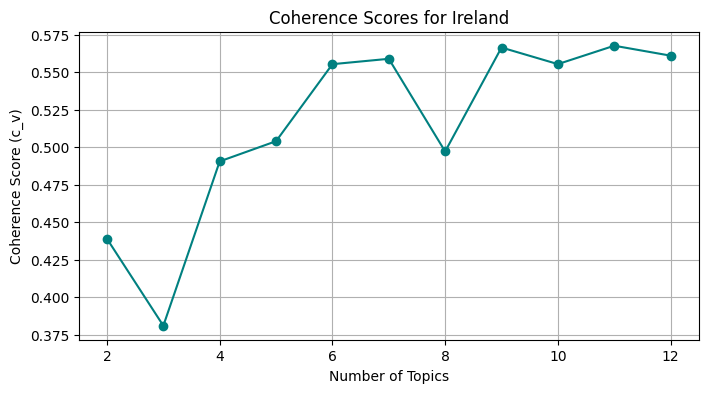

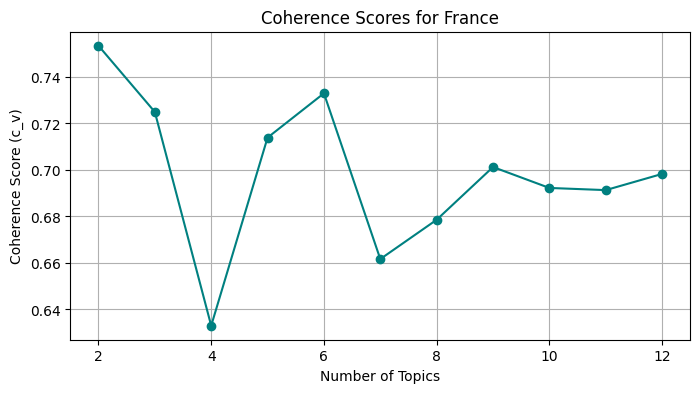

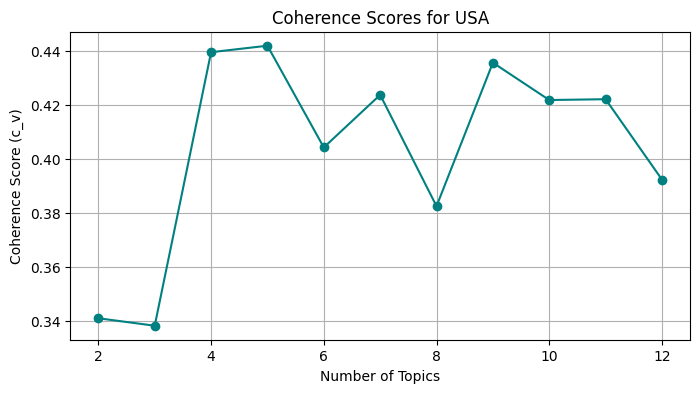

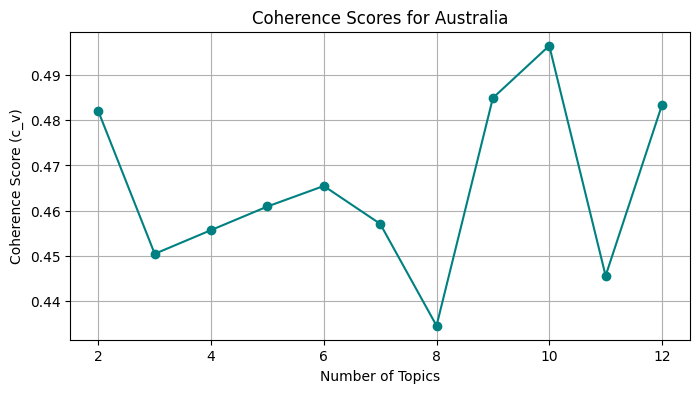

In [15]:
# Ensure the directory exists
output_dir = './img/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Iterate through results to plot and save
for country, data in country_results.items():
    plt.figure(figsize=(8, 4))
    x = range(2, len(data['coherence_scores']) + 2)
    plt.plot(x, data['coherence_scores'], marker='o', color='teal')
    
    plt.title(f'Coherence Scores for {country}')
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence Score (c_v)")
    plt.grid(True)
    
    # Save the figure to the ./img/ directory
    filename = f"{country.lower().replace(' ', '_')}_coherence.png"
    plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight')
    
    plt.show()
    plt.close() # Close plot to free up memory

In [ ]:
# Iterate through the results stored previously
for country, data in country_results.items():
    # Retrieve the optimal number of topics calculated earlier
    optimal_num_topics = data['best_num_topics']
    best_coherence = data['best_coherence']
    
    print(f"Country: {country}")
    print(f"  Optimal Number of Topics: {optimal_num_topics}")
    print(f"  Best Coherence Score: {best_coherence:.4f}")
    
    # Access the actual LDA model object for this country:
    # best_lda_model = data['model']
    # country_dictionary = data['dictionary']
    # country_corpus = data['corpus']
    
    print("-" * 40)

Country: Ireland
  Optimal Number of Topics: 11
  Best Coherence Score: 0.5676
----------------------------------------
Country: France
  Optimal Number of Topics: 2
  Best Coherence Score: 0.7534
----------------------------------------
Country: USA
  Optimal Number of Topics: 5
  Best Coherence Score: 0.4421
----------------------------------------
Country: Australia
  Optimal Number of Topics: 10
  Best Coherence Score: 0.4964
----------------------------------------


In [17]:
# Iterate through each country's results
for country, data in country_results.items():
    # Retrieve the best model for this country
    best_lda_model = data['model']
    optimal_num_topics = data['best_num_topics']
    
    print(f"\n{'='*60}")
    print(f"COUNTRY: {country.upper()}")
    print(f"Optimal Topics: {optimal_num_topics}")
    print(f"{'='*60}")
    
    # Print the topics
    print(f"Top 10 words for each of the {optimal_num_topics} topics:")
    topics = best_lda_model.print_topics(num_words=10)
    
    for topic_id, topic_content in topics:
        print(f"Topic {topic_id}: {topic_content}")
        
    print("\n")


COUNTRY: IRELAND
Optimal Topics: 11
Top 10 words for each of the 11 topics:
Topic 0: 0.011*"access" + 0.010*"strategy" + 0.010*"literacy" + 0.009*"challenge" + 0.008*"key" + 0.008*"resource" + 0.008*"address" + 0.008*"initiative" + 0.007*"outcome" + 0.007*"integration"
Topic 1: 0.026*"assessment" + 0.022*"generate" + 0.018*"guideline" + 0.011*"content" + 0.010*"learner" + 0.010*"ethical" + 0.010*"guidance" + 0.009*"source" + 0.009*"chatgpt" + 0.008*"example"
Topic 2: 0.048*"review" + 0.025*"systematic" + 0.019*"research" + 0.018*"literature" + 0.018*"paper" + 0.018*"journal" + 0.017*"analysis" + 0.017*"vol" + 0.013*"effect" + 0.010*"result"
Topic 3: 0.035*"strategy" + 0.013*"development" + 0.012*"learner" + 0.010*"assessment" + 0.010*"plan" + 0.009*"teach" + 0.009*"implementation" + 0.009*"develop" + 0.009*"framework" + 0.008*"need"
Topic 4: 0.055*"project" + 0.035*"cluster" + 0.014*"evaluation" + 0.012*"year" + 0.010*"sef" + 0.009*"meeting" + 0.008*"time" + 0.008*"coordinator" + 0.00

## Analysis of National LDA outputs

The global analysis, while effective at identifying broad thematic pillars, inevitably smooths over the distinct strategic priorities unique to each nation. A fine-grained, country-by-country LDA analysis reveals the specific "policy DNA" that characterizes each region, bridging the gap left by the aggregate view by highlighting how high-level themes like "Governance" or "Pedagogy" are operationalized differently in local contexts.

### Ireland: Fragmented administrative focus

Ireland's landscape is highly specialized, characterized by 11 distinct topics that suggest a policy environment focused on the practical management of discrete initiatives. Unlike the global "Cognitive Research" topic, Ireland isolates specific administrative processes such as "cluster evaluation," "funding," and "coordinator" roles alongside distinct, standalone strands for "literacy" and "cyberbullying." This fragmentation indicates that Irish policy is not merely about abstract strategy but is deeply concerned with the operational logistics, funding mechanisms, and specific behavioral risks (like bullying) associated with school-level implementation.

### France: Centralized pedagogical structure

France presents a stark contrast with a highly cohesive, binary structure consisting of only two topics. The high coherence score (0.75) reflects a centralized, unified narrative where the global "Pedagogical Practice" theme is strictly bifurcated. The analysis cleanly separates the **structural framework** (`cadre`, `donnée`) from the **practical application** (`enseignants`, `élèves`). This reveals a top-down pedagogical approach where the rules of engagement are clearly defined institutionally before being applied to the classroom, minimizing the ambiguity seen in other nations' datasets.

### USA: Compliance and equity metrics

The United States exhibits a compliance-centric model, revealing a preoccupation with legal frameworks that the global analysis groups broadly under "Governance." The fine-grained extraction highlights specific terms like `privacy`, `act`, and `protection`, alongside `achievement` and `socioeconomic` status. This suggests that the US landscape is heavily influenced by civil rights concerns and regulatory compliance. The focus here is less on the philosophical nature of AI and more on the legal guardrails and equitable access required to deploy it within a public school system.

### Australia: Practitioner-led discourse

Australia's output reflects a "practitioner-led" discourse that diverges significantly from the administrative tones of other countries. The prominence of terms like `respondent`, `survey`, `submission`, and `comment` indicates that the topic modeling is heavily weighted towards public consultation and stakeholder feedback. While the global analysis might group this under general strategy, the Australian data highlights a democratic, consultative process where policy formation is driven by the submissions and experiences of independent schools and teachers rather than solely by government mandate.